# CYP P450 2C19 Inhibition, Veith et al.


In [1]:
# import of all the necessary libraries
from rdkit import Chem, RDLogger
from rdkit.Chem import Lipinski, Descriptors, Crippen,rdMolDescriptors, GraphDescriptors, QED
from rdkit.Chem import Fragments, AllChem
from rdkit.Chem.rdMolDescriptors import (
    CalcTPSA, CalcKappa1, CalcKappa2, CalcKappa3,
    CalcChi0v, CalcChi1v, CalcChi2v, CalcChi3v, CalcChi4v,
    CalcChi0n, CalcChi1n, CalcChi2n, CalcChi3n, CalcChi4n,
)


RDLogger.DisableLog('rdApp.*')

from copy import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# Local utilities
import sys
sys.path.insert(0, '.')
# from utils.features import (
#     apply_featurizer,
# )

random_state = 42

In [2]:
import pandas as pd

from tdc.single_pred import ADME
data = ADME(name = 'CYP2C19_Veith')
split = data.get_split()

Found local copy...
Loading...
Done!


# Validate SMILES - Remove Invalid Molecules

In [3]:
from rdkit import Chem

# Get all data before split
train_raw = split['train']
valid_raw = split['valid']
test_raw = split['test']

# Combine all data
all_raw_data = pd.concat([train_raw, valid_raw, test_raw], ignore_index=True)

all_raw_data

,Drug_ID,Drug,Y
0,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,1
1,644851.0,Clc1ccccc1-c1nc(-c2ccccc2)n[nH]1,1
2,644968.0,COc1ccccc1CNC(=O)Cn1nnc(-c2ccncc2)n1,1
3,645063.0,CC(=O)Nc1cccc(NC(=O)C2CCCN2C(=O)Nc2ccccc2C)c1,0
4,645164.0,CCC(c1nnnn1CC1CCCO1)N(CCN1CCOCC1)Cc1cc2cc(C)cc...,0
...,...,...,...
12660,22135.0,O=S(=O)(O)c1ccc2c(N=Nc3cccc4ccccc34)c(O)c(S(=O...,0
12661,16758352.0,COC(=O)[C@H](C)NC(=O)C/C=C\[C@@H](C)CO,0
12662,5909558.0,Clc1cccc(Cl)c1CSc1nnc(/C=C/c2ccccc2)o1,1
12663,6603715.0,C=CCc1ccc([N+](C)(C)CCC(=O)CC[N+](C)(C)c2ccc(C...,0


In [4]:
from rdkit import Chem
import pandas as pd

# --- 1. SMILES Validation ---
print("=== SMILES Validation ===")
initial_count = len(all_raw_data)
print(f"Total molecules before validation: {initial_count}")

# Check if SMILES are valid and create RDKit molecules
# We use a helper function to avoid repeating the conversion
def is_valid(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

valid_mask = all_raw_data['Drug'].apply(is_valid)
all_data_valid = all_raw_data[valid_mask].copy()

n_valid = len(all_data_valid)
n_invalid = initial_count - n_valid

print(f"Valid molecules: {n_valid}")
print(f"Invalid molecules: {n_invalid}")
print(f"Percentage valid: {100*n_valid/initial_count:.2f}%")

# --- 2. Canonicalization & Duplicate Removal ---
print("\n=== Duplicate Removal ===")

# Convert SMILES to Canonical SMILES to catch all duplicates
all_data_valid['Canonical_SMILES'] = all_data_valid['Drug'].apply(
    lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x), canonical=True)
)

# Remove duplicates based on the Canonical SMILES
# 'keep=first' keeps the first occurrence found
all_data_unique = all_data_valid.drop_duplicates(subset=['Canonical_SMILES']).reset_index(drop=True)

n_unique = len(all_data_unique)
n_duplicates = n_valid - n_unique

print(f"Duplicates removed: {n_duplicates}")
print(f"Total unique molecules: {n_unique}")

# --- 3. Final Class Distribution ---
print("\n=== Final Class Distribution ===")

def print_dist(df, label):
    inh = sum(df['Y'] == 1)
    non_inh = sum(df['Y'] == 0)
    print(f"{label}: Inhibitors={inh}, Non-Inhibitors={non_inh}")

print_dist(all_raw_data, "Original ")
print_dist(all_data_unique, "Processed")

# Replace your working dataframe with the cleaned one
df_final = all_data_unique.drop(columns=['Canonical_SMILES'])

=== SMILES Validation ===
Total molecules before validation: 12665
Valid molecules: 12665
Invalid molecules: 0
Percentage valid: 100.00%

=== Duplicate Removal ===
Duplicates removed: 0
Total unique molecules: 12665

=== Final Class Distribution ===
Original : Inhibitors=5819, Non-Inhibitors=6846
Processed: Inhibitors=5819, Non-Inhibitors=6846


In [5]:
SELECTED_DESCRIPTOR_NAMES = [
    # Literature standard core
    'logp',
    'mol_wt',
    'hbond_donor',
    'hbond_acceptor',
    'tpsa',
    'num_rotatable_bonds',

    # CYP-specific structural features
    'num_aromatic_rings',
    'fr_Al_OH',
    'fr_NH2',
    'fr_COO2',

    # Electronic properties
    'max_partial_charge',
    'min_partial_charge',

    # Lightweight structural count recommended for pruning tests
    'num_heteroatoms',
]


def smiles2physchem_selected(smiles: str) -> list:
    """
    Compute a compact descriptor set aligned with the literature-standard core
    and the CYP2C19-specific features kept for downstream feature selection.

    Parameters
    ----------
    smiles : str
        A SMILES string representing a chemical molecule.

    Returns
    -------
    list
        Descriptor values in the order defined by SELECTED_DESCRIPTOR_NAMES.
        Returns a list of None values if the SMILES cannot be parsed.
    """
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return [None] * len(SELECTED_DESCRIPTOR_NAMES)

    AllChem.ComputeGasteigerCharges(molecule)

    return [
        # Literature standard core
        Crippen.MolLogP(molecule),
        Descriptors.MolWt(molecule),
        Descriptors.NumHDonors(molecule),
        Descriptors.NumHAcceptors(molecule),
        CalcTPSA(molecule),
        Descriptors.NumRotatableBonds(molecule),

        # CYP-specific structural features
        Descriptors.NumAromaticRings(molecule),
        Fragments.fr_Al_OH(molecule),
        Fragments.fr_NH2(molecule),
        Fragments.fr_COO2(molecule),

        # Electronic properties
        Descriptors.MaxPartialCharge(molecule),
        Descriptors.MinPartialCharge(molecule),

        # Lightweight structural count
        Descriptors.NumHeteroatoms(molecule),
    ]

# Backward-compatible aliases for any downstream cells still using the old names
DESCRIPTOR_NAMES = SELECTED_DESCRIPTOR_NAMES
smiles2physchem_extended = smiles2physchem_selected

In [6]:
# Re-split the cleaned data (maintain same proportions as original)
from sklearn.model_selection import train_test_split

# Calculate split proportions from original data
total = len(all_raw_data)
train_size = len(train_raw)
valid_size = len(valid_raw)
test_size = len(test_raw)

# Calculate proportions
train_prop = train_size / total
valid_prop = valid_size / total
test_prop = test_size / total

# First split: train vs (valid+test)
train_df, temp = train_test_split(
    df_final, 
    test_size=(1 - train_prop), 
    stratify=df_final['Y'], 
    random_state=42
)

# Second split: valid vs test
valid_df, test_df = train_test_split(
    temp, 
    test_size=test_prop / (valid_prop + test_prop),
    stratify=temp['Y'], 
    random_state=42
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\n=== Cleaned Dataset Split ===")
print(f"Train: {len(train_df)} molecules ({100*len(train_df)/len(df_final):.1f}%)")
print(f"Valid: {len(valid_df)} molecules ({100*len(valid_df)/len(df_final):.1f}%)")
print(f"Test: {len(test_df)} molecules ({100*len(test_df)/len(df_final):.1f}%)")


=== Cleaned Dataset Split ===
Train: 8865 molecules (70.0%)
Valid: 1266 molecules (10.0%)
Test: 2534 molecules (20.0%)


In [7]:
# Compute selected descriptors and prune highly correlated features on the training split
def build_descriptor_frame(df):
    descriptor_values = df['Drug'].apply(smiles2physchem_selected)
    descriptor_df = pd.DataFrame(descriptor_values.tolist(), columns=SELECTED_DESCRIPTOR_NAMES, index=df.index)
    return pd.concat([df.copy(), descriptor_df], axis=1)

train_desc_df = build_descriptor_frame(train_df)
valid_desc_df = build_descriptor_frame(valid_df)
test_desc_df = build_descriptor_frame(test_df)

correlation_threshold = 0.85
descriptor_corr = train_desc_df[SELECTED_DESCRIPTOR_NAMES].corr(method='spearman').abs()
upper_triangle = descriptor_corr.where(np.triu(np.ones(descriptor_corr.shape), k=1).astype(bool))
features_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > correlation_threshold)]
final_feature_columns = [feature for feature in SELECTED_DESCRIPTOR_NAMES if feature not in features_to_drop]

X_train = train_desc_df[final_feature_columns].copy()
X_valid = valid_desc_df[final_feature_columns].copy()
X_test = test_desc_df[final_feature_columns].copy()
y_train = train_desc_df['Y'].copy()
y_valid = valid_desc_df['Y'].copy()
y_test = test_desc_df['Y'].copy()

print('=== Feature Selection Summary ===')
print(f'Initial descriptor count: {len(SELECTED_DESCRIPTOR_NAMES)}')
print(f'Correlation threshold: {correlation_threshold}')
print(f'Dropped for multicollinearity: {features_to_drop}')
print(f'Final feature count: {len(final_feature_columns)}')
print(f'Final features: {final_feature_columns}')

=== Feature Selection Summary ===
Initial descriptor count: 13
Correlation threshold: 0.85
Dropped for multicollinearity: []
Final feature count: 13
Final features: ['logp', 'mol_wt', 'hbond_donor', 'hbond_acceptor', 'tpsa', 'num_rotatable_bonds', 'num_aromatic_rings', 'fr_Al_OH', 'fr_NH2', 'fr_COO2', 'max_partial_charge', 'min_partial_charge', 'num_heteroatoms']


In [8]:
train_desc_df

,Drug_ID,Drug,Y,logp,mol_wt,hbond_donor,hbond_acceptor,tpsa,num_rotatable_bonds,num_aromatic_rings,fr_Al_OH,fr_NH2,fr_COO2,max_partial_charge,min_partial_charge,num_heteroatoms
0,3232879.0,COc1ccc(-n2c(=O)c(-c3cccs3)nc3cncnc32)cc1,1,2.91280,336.376,0,6,69.90,3,4,0,0,0,0.283674,-0.496766,7
1,1046869.0,FC(F)(F)c1nc(-c2ccncc2)ncc1-c1nnnn1-c1ccccc1,1,3.20010,369.310,0,6,82.27,3,4,0,0,0,0.433728,-0.264688,10
2,3233476.0,COc1ccc(NC(=O)N2CC[C@@]3(CCCN(C(=O)c4c(C)noc4C...,0,3.46024,412.490,1,5,87.91,3,2,0,0,0,0.321359,-0.496766,8
3,9666196.0,CCOc1ccc(N(C(C)C(=O)N/N=C(\C)c2cccc(NC(=O)c3cc...,1,4.03250,522.627,2,6,117.17,10,3,0,0,0,0.263171,-0.493887,10
4,229466.0,OCCSCc1cc(Cl)cc(Cl)c1O,0,2.92450,253.150,2,3,40.46,4,1,1,0,0,0.137801,-0.506069,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8860,2048125.0,CCOC(=O)c1cnc(-n2nc(C)cc2C)nc1NCCO,0,0.86004,305.338,2,7,102.16,6,2,1,0,0,0.342991,-0.462252,8
8861,2981360.0,Cc1nn(C(C)C(=O)Nc2ccc(Cl)cn2)c(C)c1[N+](=O)[O-],1,2.65624,323.740,1,5,102.95,4,2,0,0,0,0.312271,-0.308835,9
8862,16758252.0,CO[C@@H]1COC(=O)C/C=C\[C@@H](C)[C@@H]2C=C[C@@H...,0,1.95070,394.464,1,7,91.29,1,0,1,0,0,0.309222,-0.462659,7
8863,1234753.0,COC(=O)c1nnn(Cc2ccccc2)c1N,0,0.69520,232.243,1,5,83.03,3,2,0,1,0,0.362029,-0.464138,6


In [9]:
# Add Morgan fingerprints (ECFP4) as a structural benchmark
from rdkit import DataStructs

MORGAN_RADIUS = 2  # ECFP4
MORGAN_NBITS = 1024

def smiles_to_morgan_fp(smiles: str, n_bits: int = MORGAN_NBITS, radius: int = MORGAN_RADIUS) -> np.ndarray:
    mol = Chem.MolFromSmiles(smiles)
    fp_array = np.zeros((n_bits,), dtype=np.int8)
    if mol is None:
        return fp_array
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    DataStructs.ConvertToNumpyArray(fp, fp_array)
    return fp_array

def build_morgan_frame(df):
    fp_matrix = np.vstack(df['Drug'].apply(smiles_to_morgan_fp).to_numpy())
    fp_columns = [f'ecfp4_{i}' for i in range(MORGAN_NBITS)]
    return pd.DataFrame(fp_matrix, columns=fp_columns, index=df.index)

train_fp_df = build_morgan_frame(train_df)
valid_fp_df = build_morgan_frame(valid_df)
test_fp_df = build_morgan_frame(test_df)

# Curated descriptors + fingerprints = strong benchmark representation
X_train_benchmark = pd.concat([X_train, train_fp_df], axis=1)
X_valid_benchmark = pd.concat([X_valid, valid_fp_df], axis=1)
X_test_benchmark = pd.concat([X_test, test_fp_df], axis=1)

print('=== Morgan Fingerprint Benchmark ===')
print(f'Fingerprint length: {MORGAN_NBITS} bits')
print(f'ECFP radius: {MORGAN_RADIUS} (ECFP4)')
print(f'Benchmark feature count: {X_train_benchmark.shape[1]}')
print(f'Curated descriptors kept: {X_train.shape[1]}')
print(f'Fingerprint bits added: {train_fp_df.shape[1]}')

=== Morgan Fingerprint Benchmark ===
Fingerprint length: 1024 bits
ECFP radius: 2 (ECFP4)
Benchmark feature count: 1037
Curated descriptors kept: 13
Fingerprint bits added: 1024


# Exploratory Data Analysis (EDA)

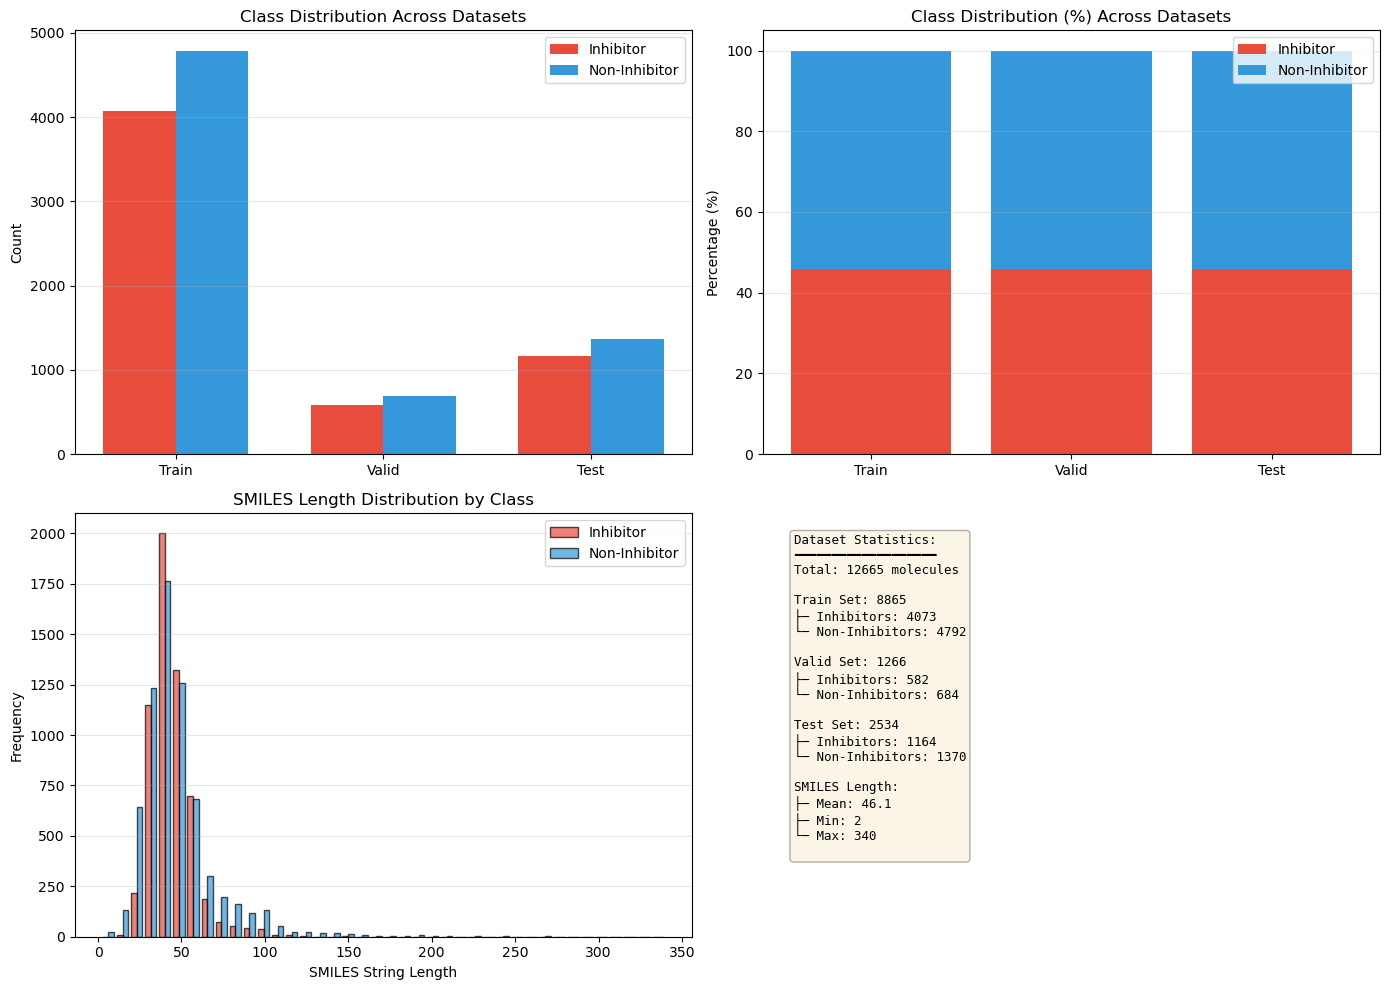

=== EDA Summary ===
Inhibitors: 5819 (45.9%)
Non-Inhibitors: 6846 (54.1%)
SMILES Length - Mean: 46.1, Std: 20.0


In [10]:
# Class Distribution Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from rdkit.Chem import Descriptors

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class distribution across datasets
datasets = ['Train', 'Valid', 'Test']
inhibitor_counts = [
    sum(train_df['Y'] == 1),
    sum(valid_df['Y'] == 1),
    sum(test_df['Y'] == 1)
]
non_inhibitor_counts = [
    sum(train_df['Y'] == 0),
    sum(valid_df['Y'] == 0),
    sum(test_df['Y'] == 0)
]

x = np.arange(len(datasets))
width = 0.35
axes[0, 0].bar(x - width/2, inhibitor_counts, width, label='Inhibitor', color='#e74c3c')
axes[0, 0].bar(x + width/2, non_inhibitor_counts, width, label='Non-Inhibitor', color='#3498db')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Class Distribution Across Datasets')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(datasets)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Percentage stacked bar
dataset_sizes = [len(train_df), len(valid_df), len(test_df)]
percentages_inhibitor = [c / size * 100 for c, size in zip(inhibitor_counts, dataset_sizes)]
percentages_non = [100 - p for p in percentages_inhibitor]

axes[0, 1].bar(datasets, percentages_inhibitor, label='Inhibitor', color='#e74c3c')
axes[0, 1].bar(datasets, percentages_non, bottom=percentages_inhibitor, 
               label='Non-Inhibitor', color='#3498db')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_title('Class Distribution (%) Across Datasets')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. SMILES length distribution
df_final['smiles_length'] = df_final['Drug'].apply(len)

axes[1, 0].hist([df_final[df_final['Y']==1]['smiles_length'],
                 df_final[df_final['Y']==0]['smiles_length']],
                bins=40, label=['Inhibitor', 'Non-Inhibitor'], 
                color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('SMILES String Length')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('SMILES Length Distribution by Class')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Statistics summary
stats_text = f"""Dataset Statistics:
━━━━━━━━━━━━━━━━━━━
Total: {len(df_final)} molecules

Train Set: {len(train_df)}
├─ Inhibitors: {sum(train_df['Y']==1)}
└─ Non-Inhibitors: {sum(train_df['Y']==0)}

Valid Set: {len(valid_df)}
├─ Inhibitors: {sum(valid_df['Y']==1)}
└─ Non-Inhibitors: {sum(valid_df['Y']==0)}

Test Set: {len(test_df)}
├─ Inhibitors: {sum(test_df['Y']==1)}
└─ Non-Inhibitors: {sum(test_df['Y']==0)}

SMILES Length:
├─ Mean: {df_final['smiles_length'].mean():.1f}
├─ Min: {df_final['smiles_length'].min()}
└─ Max: {df_final['smiles_length'].max()}
"""
axes[1, 1].text(0.05, 0.95, stats_text, transform=axes[1, 1].transAxes,
                fontfamily='monospace', fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("=== EDA Summary ===")
print(f"Inhibitors: {sum(df_final['Y']==1)} ({100*sum(df_final['Y']==1)/len(df_final):.1f}%)")
print(f"Non-Inhibitors: {sum(df_final['Y']==0)} ({100*sum(df_final['Y']==0)/len(df_final):.1f}%)")
print(f"SMILES Length - Mean: {df_final['smiles_length'].mean():.1f}, Std: {df_final['smiles_length'].std():.1f}")

Computing molecular descriptors... (this may take a moment)

Molecular Weight:
  Inhibitors - Mean: 367.30, Std: 83.26
  Non-Inhibitors - Mean: 347.72, Std: 122.72

LogP (Lipophilicity):
  Inhibitors - Mean: 3.72, Std: 1.30
  Non-Inhibitors - Mean: 2.31, Std: 2.09

H-Bond Donors:
  Inhibitors - Mean: 0.99, Std: 0.86
  Non-Inhibitors - Mean: 1.44, Std: 1.54

H-Bond Acceptors:
  Inhibitors - Mean: 4.42, Std: 1.70
  Non-Inhibitors - Mean: 4.79, Std: 2.47

Rotatable Bonds:
  Inhibitors - Mean: 4.84, Std: 2.25
  Non-Inhibitors - Mean: 4.26, Std: 2.72

Ring Count:
  Inhibitors - Mean: 3.32, Std: 1.15
  Non-Inhibitors - Mean: 3.03, Std: 1.49


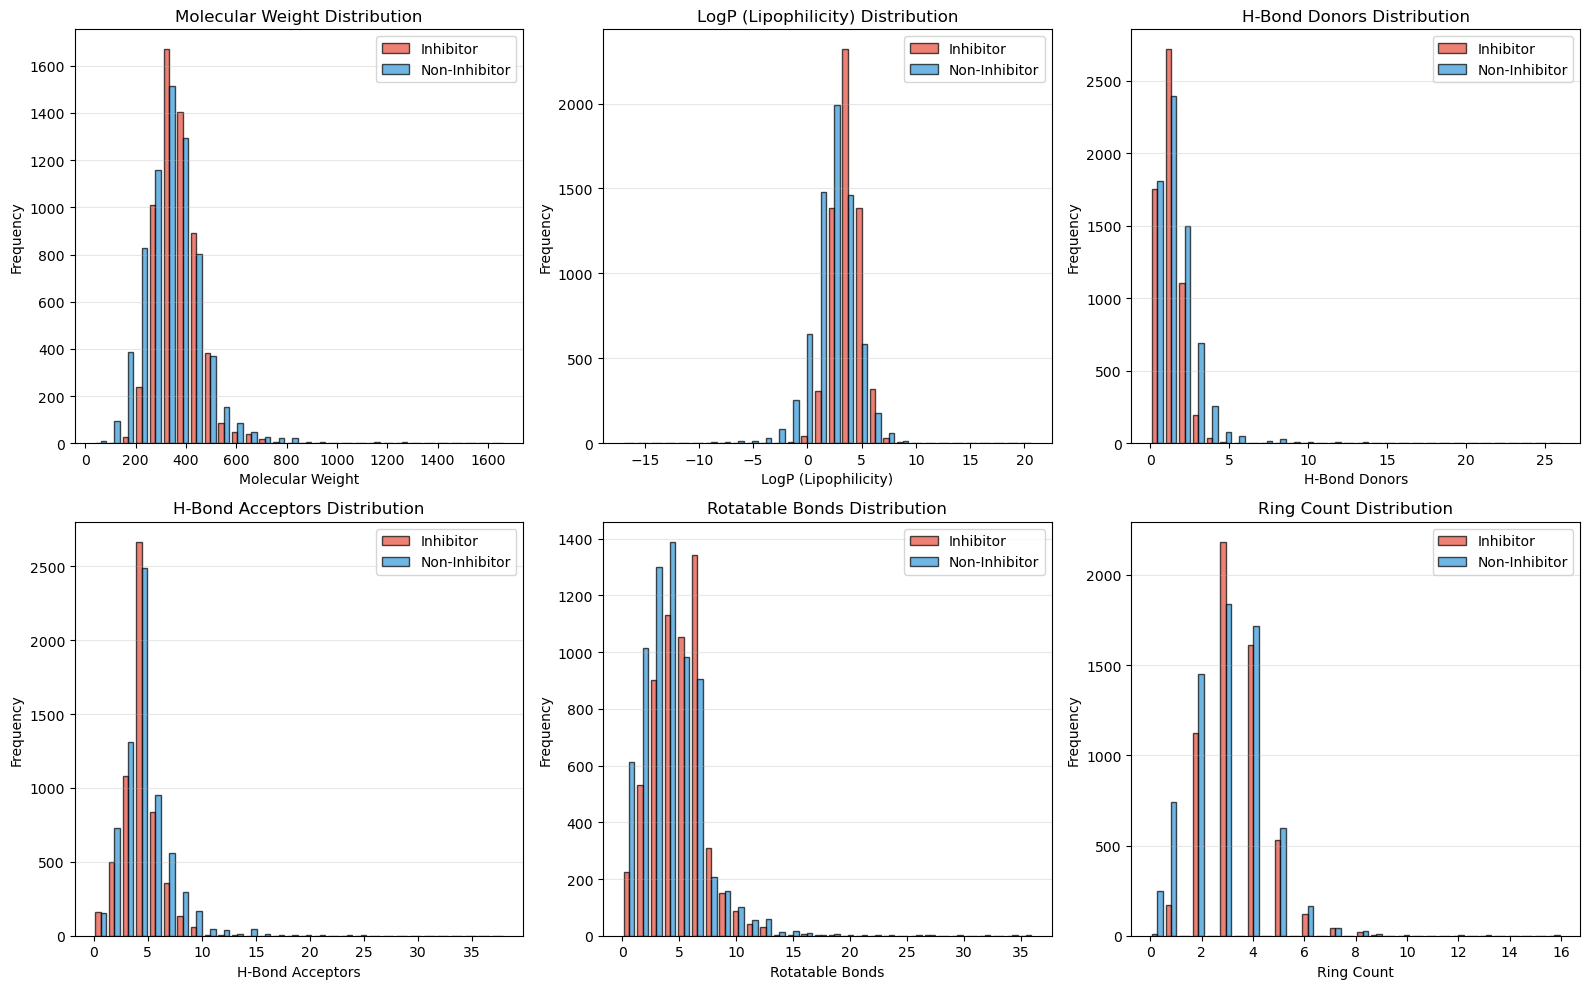

In [11]:
# Molecular Properties Analysis
import numpy as np

# Compute molecular descriptors
def compute_descriptors(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return {
                'MW': Descriptors.MolWt(mol),
                'LogP': Descriptors.MolLogP(mol),
                'HBD': Descriptors.NumHDonors(mol),
                'HBA': Descriptors.NumHAcceptors(mol),
                'RotBonds': Descriptors.NumRotatableBonds(mol),
                'Rings': Descriptors.RingCount(mol)
            }
    except:
        pass
    return {k: np.nan for k in ['MW', 'LogP', 'HBD', 'HBA', 'RotBonds', 'Rings']}

print("Computing molecular descriptors... (this may take a moment)")
descriptors_list = df_final['Drug'].apply(compute_descriptors)
descriptors_df = pd.DataFrame(list(descriptors_list))
all_data_with_desc = pd.concat([df_final, descriptors_df], axis=1) 

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

properties = ['MW', 'LogP', 'HBD', 'HBA', 'RotBonds', 'Rings']
titles = ['Molecular Weight', 'LogP (Lipophilicity)', 'H-Bond Donors', 
          'H-Bond Acceptors', 'Rotatable Bonds', 'Ring Count']

for idx, (prop, title) in enumerate(zip(properties, titles)):
    inhibitors = all_data_with_desc[all_data_with_desc['Y'] == 1][prop]
    non_inhibitors = all_data_with_desc[all_data_with_desc['Y'] == 0][prop]
    
    axes[idx].hist([inhibitors, non_inhibitors], bins=30, 
                   label=['Inhibitor', 'Non-Inhibitor'],
                   color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel(title)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{title} Distribution')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3, axis='y')
    
    # Print statistics
    print(f"\n{title}:")
    print(f"  Inhibitors - Mean: {inhibitors.mean():.2f}, Std: {inhibitors.std():.2f}")
    print(f"  Non-Inhibitors - Mean: {non_inhibitors.mean():.2f}, Std: {non_inhibitors.std():.2f}")

plt.tight_layout()
plt.show()


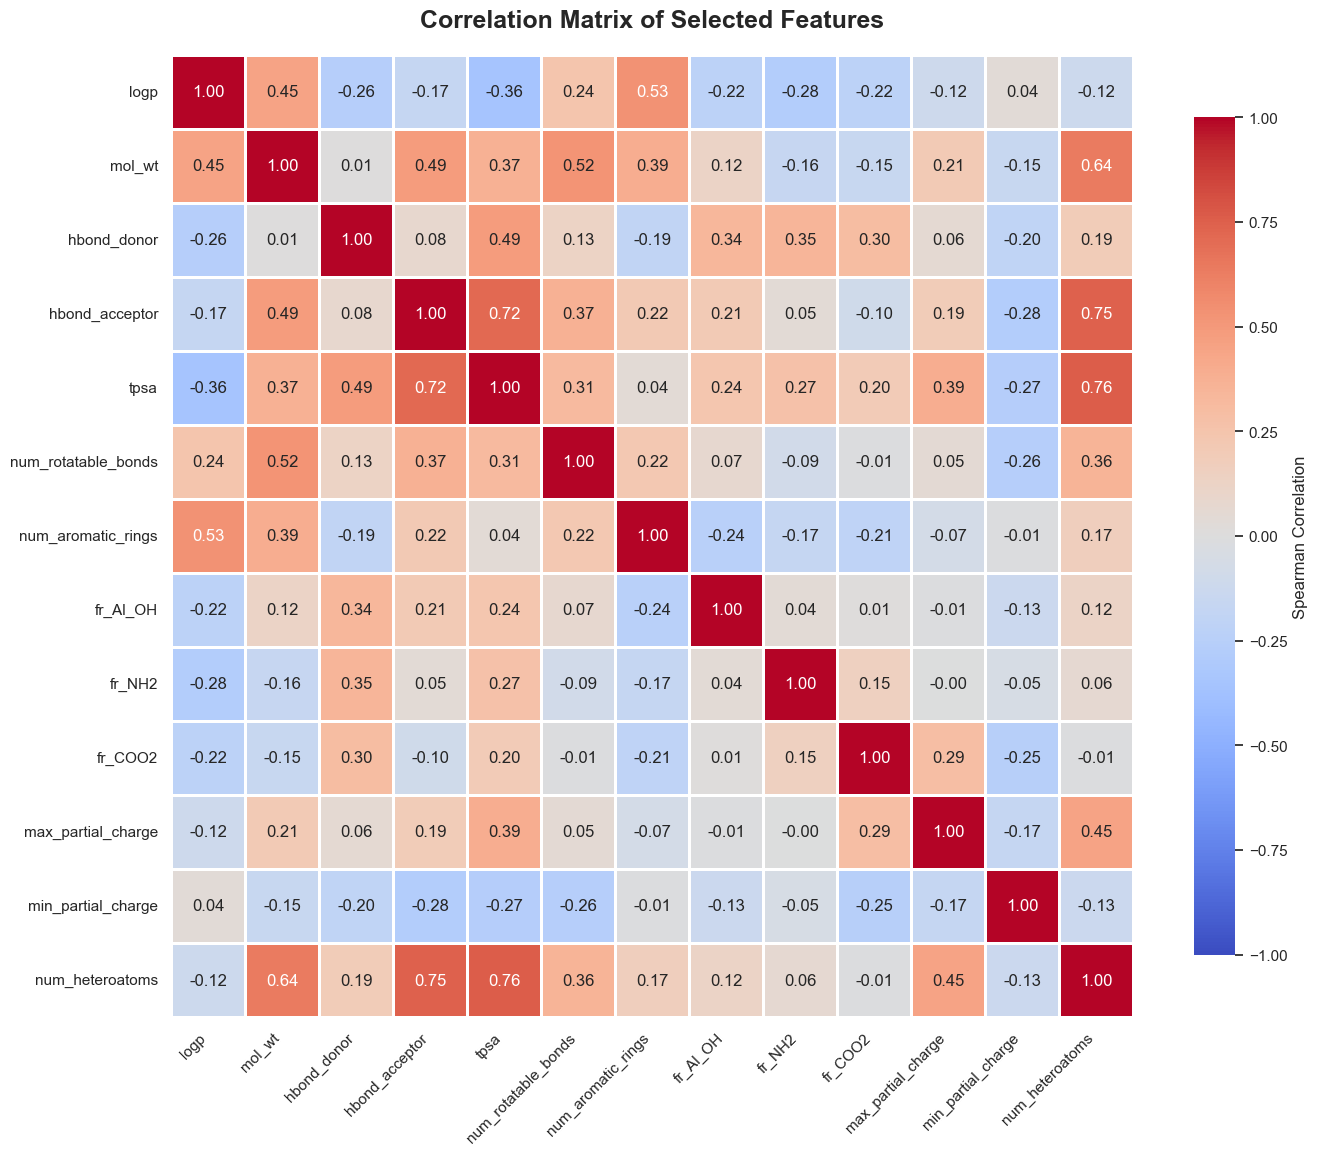

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate the correlation matrix on the new features (X_train)
# Using Spearman correlation since the data might not be normally distributed
corr_matrix = X_train.corr(method='spearman')

# 2. Set the Seaborn style and figure size
sns.set_theme(style="white")
plt.figure(figsize=(14, 12))

# 3. Create the Heatmap (Full Matrix / No Mask)
sns.heatmap(
    corr_matrix, 
    cmap='coolwarm',      
    vmax=1.0, vmin=-1.0,  
    center=0,
    annot=True,           
    fmt=".2f",             
    square=True,          
    linewidths=1.0,       
    cbar_kws={"shrink": .8, "label": "Spearman Correlation"}
)

# 4. Customize titles and fonts
plt.title('Correlation Matrix of Selected Features', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

=== Sample CYP2C19 Inhibitors ===


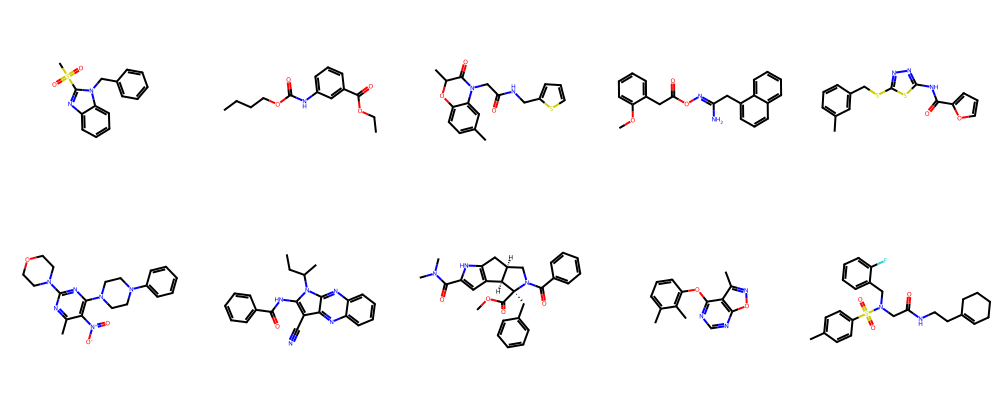


=== Sample Non-Inhibitors ===


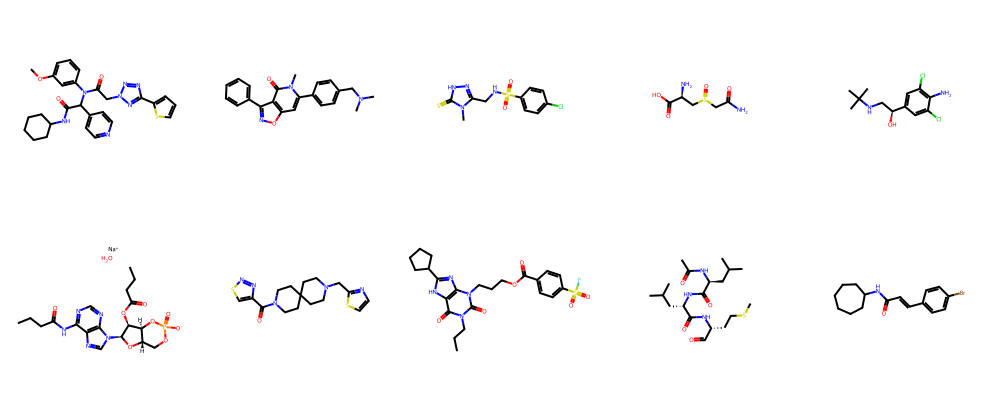

In [14]:
# Visualize Sample Molecules from Each Class
from IPython.display import display
from rdkit.Chem import Draw

# Get 10 random inhibitors and non-inhibitors
inhibitors_sample = df_final[df_final['Y'] == 1].sample(min(10, sum(df_final['Y']==1)), random_state=42)
non_inhibitors_sample = df_final[df_final['Y'] == 0].sample(min(10, sum(df_final['Y']==0)), random_state=42)

# Parse molecules
inhibitor_mols = []
for smiles in inhibitors_sample['Drug']:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        inhibitor_mols.append(mol)

non_inhibitor_mols = []
for smiles in non_inhibitors_sample['Drug']:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        non_inhibitor_mols.append(mol)

# Display
print("=== Sample CYP2C19 Inhibitors ===")
if inhibitor_mols:
    img = Draw.MolsToGridImage(inhibitor_mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)

print("\n=== Sample Non-Inhibitors ===")
if non_inhibitor_mols:
    img = Draw.MolsToGridImage(non_inhibitor_mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)


Training Random Forest...

Model Accuracy on Test Set: 0.7786

Classification Report:
                   precision    recall  f1-score   support

Non-Inhibitor (0)       0.79      0.80      0.80      1370
    Inhibitor (1)       0.76      0.75      0.76      1164

         accuracy                           0.78      2534
        macro avg       0.78      0.78      0.78      2534
     weighted avg       0.78      0.78      0.78      2534



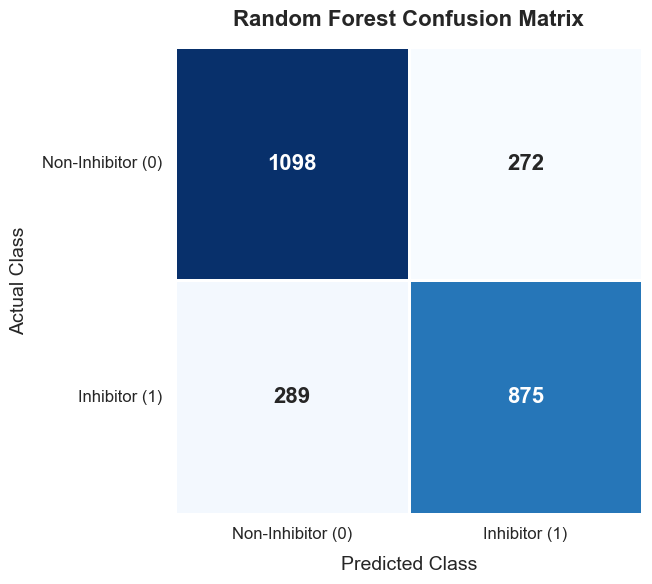

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the Random Forest Classifier
# n_estimators=100 is a good default. n_jobs=-1 uses all CPU cores for faster training.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model on the training data
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = rf_model.predict(X_test)

# 4. Print the text-based evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on Test Set: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Inhibitor (0)', 'Inhibitor (1)']))

# 5. Plot the beautiful Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d',                # Use 'd' for integer formatting
    cmap='Blues',           # Clean blue color scale
    cbar=False,             # Hide color bar for a cleaner look
    square=True,            # Make it a perfect cube/square
    linewidths=2,
    annot_kws={"size": 16, "weight": "bold"}
)

plt.title('Random Forest Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Class', fontsize=14, labelpad=10)
plt.ylabel('Actual Class', fontsize=14, labelpad=10)

# Set the class names on the axes
class_names = ['Non-Inhibitor (0)', 'Inhibitor (1)']
plt.xticks(ticks=[0.5, 1.5], labels=class_names, fontsize=12)
plt.yticks(ticks=[0.5, 1.5], labels=class_names, fontsize=12, rotation=0)

plt.tight_layout()
plt.show()

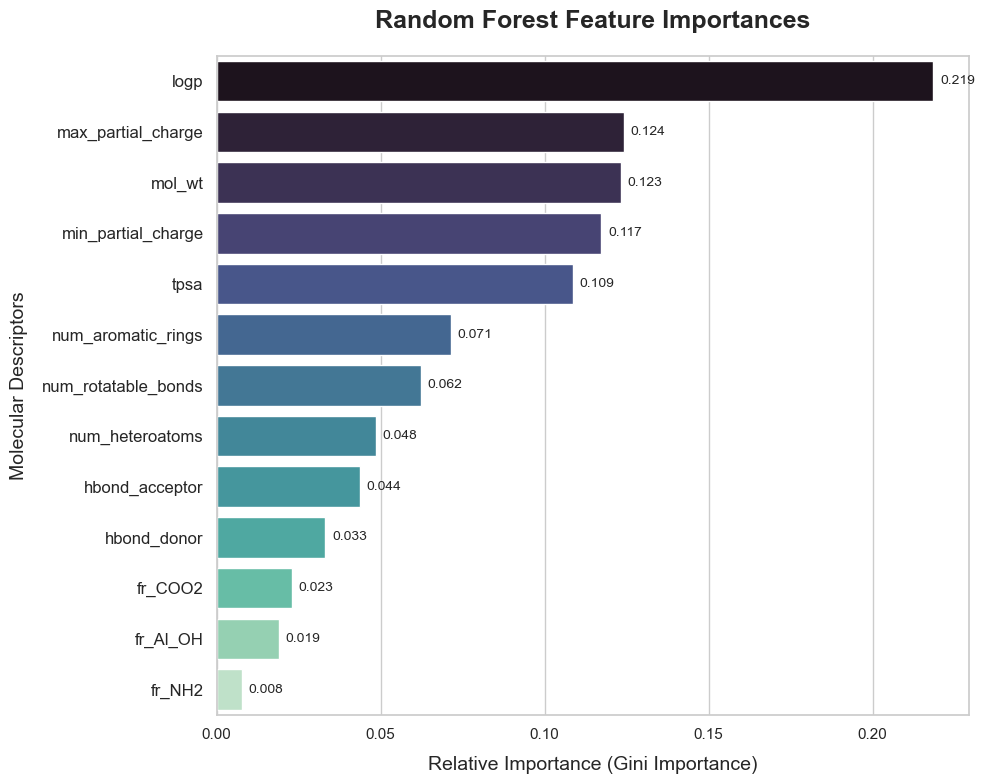

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importances and names from the trained Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

# 2. Create a Pandas DataFrame to hold and sort the data
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Set up the visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

# 5. Create a horizontal bar plot
# Using a nice color palette like 'viridis' or 'mako' for a professional look
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    palette='mako'
)

# 6. Customize titles and labels
plt.title('Random Forest Feature Importances', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Relative Importance (Gini Importance)', fontsize=14, labelpad=10)
plt.ylabel('Molecular Descriptors', fontsize=14, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=12)

# Add exact values at the end of each bar for clarity
for index, value in enumerate(importance_df['Importance']):
    plt.text(value + 0.002, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()